# 05 — Gold chunk density analysis

Before picking a final retrieval configuration, I wanted to know how much
of each document actually contains the information that matters (the
quotes annotated in the golden dataset).

The question: what is the minimum coverage a retrieval system needs to
theoretically capture all relevant information?

If golden quotes live in only ~13 % of chunks, then a retriever reading
80 % of the document is spending most of its budget on irrelevant text.
That is expected since the retriever cannot know which chunks are gold
ahead of time, but it helps interpret what coverage numbers actually mean.

I also look at the full corpus (176 documents) to see how long the documents are.

In [1]:
import csv
import json
import os
import re
import statistics
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# paths
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
GOLDEN_CSV = os.path.join(PROJECT_ROOT, "data/05_retrieval_evaluation/golden_dataset_template.csv")
CHUNK_DIR = os.path.join(PROJECT_ROOT, "data/03_chunked_docs")
CHUNK_STRATEGY = "OPENAI_PARA"  # paragraph-level chunking, the one we use in final pipeline


def clean_text(text: str) -> str:
    """Normalize text the same way evaluate_retrieval.py does."""
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text


def load_golden_dataset():
    rows = []
    with open(GOLDEN_CSV, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f, delimiter=";")
        for row in reader:
            rows.append(row)
    return rows


def load_chunks(doc_base_name: str):
    path = os.path.join(CHUNK_DIR, f"{doc_base_name}_chunks_{CHUNK_STRATEGY}.json")
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def extract_quotes(row, columns):
    quotes = []
    for col in columns:
        val = row.get(col, "")
        if val:
            quotes.extend([q.strip() for q in val.split("|") if q.strip()])
    return quotes


def find_gold_chunk_ids(chunks, quotes):
    """For each quote, find which chunk contains it via substring match."""
    gold_ids = set()
    not_found = []
    for quote in quotes:
        clean_q = clean_text(quote)
        found = False
        for i, chunk in enumerate(chunks):
            if clean_q in clean_text(chunk["page_content"]):
                gold_ids.add(i)
                found = True
                break
        if not found:
            not_found.append(quote)
    return gold_ids, not_found


golden = load_golden_dataset()
print(f"Loaded {len(golden)} documents from golden dataset")

Loaded 20 documents from golden dataset


## 1 — Gold chunk density per document

For each document I count how many paragraph chunks contain at least one expert-annotated quote.
This tells me what fraction of the document is "gold" (needed for correct extraction).

In [2]:
ALL_QUOTE_COLS = ["q1_context_quotes", "q2_penalty_quotes", "q3_moderation_quotes"]

results = []

for row in golden:
    doc_name = row["document_name"]
    base = doc_name.replace(".json", "")
    short = base.replace("_00_dokument", "")
    chunks = load_chunks(base)
    all_quotes = extract_quotes(row, ALL_QUOTE_COLS)
    gold_ids, not_found = find_gold_chunk_ids(chunks, all_quotes)

    results.append({
        "doc": short,
        "gold_chunks": len(gold_ids),
        "total_chunks": len(chunks),
        "gold_pct": len(gold_ids) / len(chunks) * 100,
        "gold_ids": sorted(gold_ids),
        "n_quotes": len(all_quotes),
        "not_found": not_found,
    })

print(f"{'Document':<45s} | Gold | Total | Gold%  | Quotes")
print("-" * 80)
for r in results:
    warn = f"  (!) {len(r['not_found'])} quotes not matched" if r["not_found"] else ""
    print(f"{r['doc']:<45s} | {r['gold_chunks']:4d} | {r['total_chunks']:5d} | {r['gold_pct']:5.1f}% | {r['n_quotes']:2d}{warn}")

total_gold = sum(r["gold_chunks"] for r in results)
total_chunks = sum(r["total_chunks"] for r in results)
avg_pct = np.mean([r["gold_pct"] for r in results])
print("-" * 80)
print(f"{'TOTAL':<45s} | {total_gold:4d} | {total_chunks:5d} | {total_gold/total_chunks*100:5.1f}%")
print(f"{'AVERAGE (per document)':<45s} |      |       | {avg_pct:5.1f}%")

Document                                      | Gold | Total | Gold%  | Quotes
--------------------------------------------------------------------------------
NS_SR_1Cdo_85_2023                            |    1 |    24 |   4.2% |  8
KS_Bratislava_1Cob_40_2018                    |    3 |    32 |   9.4% |  6
KS_Bratislava_1Cob_130_2019                   |    4 |    21 |  19.0% |  7
NS_SR_1Obdo_66_2018                           |    2 |    27 |   7.4% |  8
NS_SR_1Obdo_72_2019                           |    4 |    40 |  10.0% |  9
KS_Bratislava_2Co_380_2011                    |    4 |    17 |  23.5% | 11
KS_Trenčín_8Cob_64_2011                       |    7 |    20 |  35.0% |  9
KS_Trenčín_8Cob_258_2014                      |    2 |    17 |  11.8% |  9
KS_Trnava_32Cob_3_2021                        |    4 |    28 |  14.3% | 10
KS_Banská_Bystrica_43CoPv_10_2023             |    5 |    52 |   9.6% |  8
KS_Žilina_14Cob_109_2017                      |    5 |    54 |   9.3% | 12
KS_Žilina_14Cob

## 2 — Per-LLM-call breakdown

The extraction pipeline makes two LLM calls per document:
- **Call 1** extracts breach context (q1) + penalty details (q2)
- **Call 2** extracts court decision, reasoning, and moderation factors (q3)

Each call retrieves its own chunks. How many gold chunks does each call actually need?

In [3]:
call_results = []

for row in golden:
    doc_name = row["document_name"]
    base = doc_name.replace(".json", "")
    short = base.replace("_00_dokument", "")
    chunks = load_chunks(base)
    n = len(chunks)

    call1_quotes = extract_quotes(row, ["q1_context_quotes", "q2_penalty_quotes"])
    call1_ids, _ = find_gold_chunk_ids(chunks, call1_quotes)

    call2_quotes = extract_quotes(row, ["q3_moderation_quotes"])
    call2_ids, _ = find_gold_chunk_ids(chunks, call2_quotes)

    all_ids = call1_ids | call2_ids

    call_results.append({
        "doc": short, "n": n,
        "call1": len(call1_ids), "call1_pct": len(call1_ids) / n * 100,
        "call2": len(call2_ids), "call2_pct": len(call2_ids) / n * 100,
        "all": len(all_ids), "all_pct": len(all_ids) / n * 100,
    })

print(f"{'Document':<45s} | Call 1 need  | Call 2 need  | All unique")
print("-" * 90)
for r in call_results:
    print(
        f"{r['doc']:<45s} | "
        f"{r['call1']:2d}/{r['n']:2d} ({r['call1_pct']:4.0f}%) | "
        f"{r['call2']:2d}/{r['n']:2d} ({r['call2_pct']:4.0f}%) | "
        f"{r['all']:2d}/{r['n']:2d} ({r['all_pct']:4.0f}%)")
print("-" * 90)
print(
    f"{'AVERAGE':<45s} | "
    f"     ({np.mean([r['call1_pct'] for r in call_results]):4.0f}%) | "
    f"     ({np.mean([r['call2_pct'] for r in call_results]):4.0f}%) | "
    f"     ({np.mean([r['all_pct'] for r in call_results]):4.0f}%)")

Document                                      | Call 1 need  | Call 2 need  | All unique
------------------------------------------------------------------------------------------
NS_SR_1Cdo_85_2023                            |  1/24 (   4%) |  1/24 (   4%) |  1/24 (   4%)
KS_Bratislava_1Cob_40_2018                    |  2/32 (   6%) |  1/32 (   3%) |  3/32 (   9%)
KS_Bratislava_1Cob_130_2019                   |  3/21 (  14%) |  2/21 (  10%) |  4/21 (  19%)
NS_SR_1Obdo_66_2018                           |  2/27 (   7%) |  1/27 (   4%) |  2/27 (   7%)
NS_SR_1Obdo_72_2019                           |  3/40 (   8%) |  1/40 (   2%) |  4/40 (  10%)
KS_Bratislava_2Co_380_2011                    |  2/17 (  12%) |  2/17 (  12%) |  4/17 (  24%)
KS_Trenčín_8Cob_64_2011                       |  4/20 (  20%) |  3/20 (  15%) |  7/20 (  35%)
KS_Trenčín_8Cob_258_2014                      |  1/17 (   6%) |  2/17 (  12%) |  2/17 (  12%)
KS_Trnava_32Cob_3_2021                        |  2/28 (   7%) |  2/2

## 3 — Document sizes across the full corpus

The golden dataset only has 10 documents. The full corpus has 176 court decisions of varying length.
I want to check how long they actually are and whether just feeding the whole document
to the LLM (without RAG) would be a realistic alternative.

In [4]:
all_chunk_files = [f for f in os.listdir(CHUNK_DIR) if f.endswith(f"_{CHUNK_STRATEGY}.json")]

corpus_stats = []
for fname in sorted(all_chunk_files):
    with open(os.path.join(CHUNK_DIR, fname), "r", encoding="utf-8") as f:
        chunks = json.load(f)
    total_chars = sum(len(c["page_content"]) for c in chunks)
    approx_tokens = total_chars // 4  # rough char/token ratio for Slovak
    short = fname.replace("_00_dokument_chunks_OPENAI_PARA.json", "")
    corpus_stats.append({"name": short, "n_chunks": len(chunks),
                         "total_chars": total_chars, "approx_tokens": approx_tokens})

corpus_stats.sort(key=lambda x: x["n_chunks"])
chunks_list = [d["n_chunks"] for d in corpus_stats]
tokens_list = [d["approx_tokens"] for d in corpus_stats]

print(f"Total documents in corpus: {len(corpus_stats)}")
print(f"Chunks per document:  min={min(chunks_list)}, median={statistics.median(chunks_list):.0f}, "
      f"mean={statistics.mean(chunks_list):.1f}, max={max(chunks_list)}")
print(f"Approx tokens per doc: min={min(tokens_list)}, median={statistics.median(tokens_list):.0f}, "
      f"mean={statistics.mean(tokens_list):.0f}, max={max(tokens_list)}")
print()

print("Chunk count distribution:")
buckets = [(0, 5), (5, 10), (10, 15), (15, 20), (20, 30), (30, 50), (50, 100)]
for lo, hi in buckets:
    count = sum(1 for d in corpus_stats if lo <= d["n_chunks"] < hi)
    bar = "#" * count
    print(f"  {lo:2d}-{hi:2d} chunks: {count:3d} docs ({count/len(corpus_stats)*100:4.1f}%)  {bar}")

print()
print("How many documents fit within a given token budget?")
print("(After reserving space for prompt instructions + output)")
for budget in [5_000, 10_000, 20_000, 30_000]:
    fits = sum(1 for d in corpus_stats if d["approx_tokens"] < budget)
    print(f"  {budget//1000}k tokens: {fits}/{len(corpus_stats)} ({fits/len(corpus_stats)*100:.0f}%)")

print()
chunk_sizes = []
for fname in all_chunk_files:
    with open(os.path.join(CHUNK_DIR, fname), "r", encoding="utf-8") as f:
        chunks = json.load(f)
    for c in chunks:
        chunk_sizes.append(len(c["page_content"]) // 4)

avg_chunk = statistics.mean(chunk_sizes)
print(f"With RAG (top_k=7 final config, 2 LLM calls):")
print(f"  Avg chunk: ~{avg_chunk:.0f} tokens")
print(f"  Per document: ~{2 * 7 * avg_chunk:.0f} tokens (2 calls x 7 chunks)")
print(f"  vs whole document avg: ~{statistics.mean(tokens_list):.0f} tokens")
print(f"  Savings: ~{(1 - (2*7*avg_chunk) / statistics.mean(tokens_list)) * 100:.0f}%")

Total documents in corpus: 176
Chunks per document:  min=3, median=27, mean=31.0, max=112
Approx tokens per doc: min=1353, median=5762, mean=7592, max=30112

Chunk count distribution:
   0- 5 chunks:   4 docs ( 2.3%)  ####
   5-10 chunks:   6 docs ( 3.4%)  ######
  10-15 chunks:  15 docs ( 8.5%)  ###############
  15-20 chunks:  26 docs (14.8%)  ##########################
  20-30 chunks:  46 docs (26.1%)  ##############################################
  30-50 chunks:  57 docs (32.4%)  #########################################################
  50-100 chunks:  21 docs (11.9%)  #####################

How many documents fit within a given token budget?
(After reserving space for prompt instructions + output)
  5k tokens: 65/176 (37%)
  10k tokens: 137/176 (78%)
  20k tokens: 169/176 (96%)
  30k tokens: 175/176 (99%)

With RAG (top_k=4, 2 LLM calls):
  Avg chunk: ~245 tokens
  Per document: ~1959 tokens (2 calls x 4 chunks)
  vs whole document avg: ~7592 tokens
  Savings: ~74%


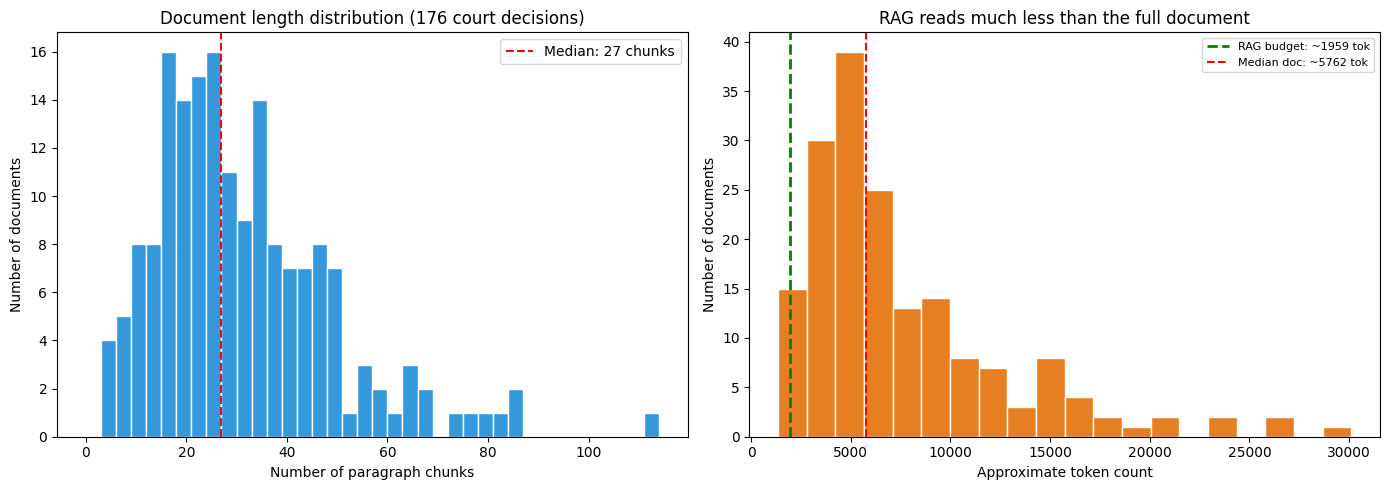

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: histogram of chunk counts across corpus
ax = axes[0]
ax.hist(chunks_list, bins=range(0, max(chunks_list) + 3, 3), color="#3498db", edgecolor="white")
ax.axvline(statistics.median(chunks_list), color="red", linestyle="--", linewidth=1.5,
           label=f"Median: {statistics.median(chunks_list):.0f} chunks")
ax.set_xlabel("Number of paragraph chunks")
ax.set_ylabel("Number of documents")
ax.set_title("Document length distribution (176 court decisions)")
ax.legend()

# right: token counts, with RAG budget vs full document
ax = axes[1]
ax.hist(tokens_list, bins=20, color="#e67e22", edgecolor="white")
ax.axvline(2 * 4 * avg_chunk, color="green", linestyle="--", linewidth=2,
           label=f"RAG budget: ~{2*4*avg_chunk:.0f} tok")
ax.axvline(statistics.median(tokens_list), color="red", linestyle="--", linewidth=1.5,
           label=f"Median doc: ~{statistics.median(tokens_list):.0f} tok")
ax.set_xlabel("Approximate token count")
ax.set_ylabel("Number of documents")
ax.set_title("RAG reads much less than the full document")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4 — Gold density vs document size + retrieval comparison

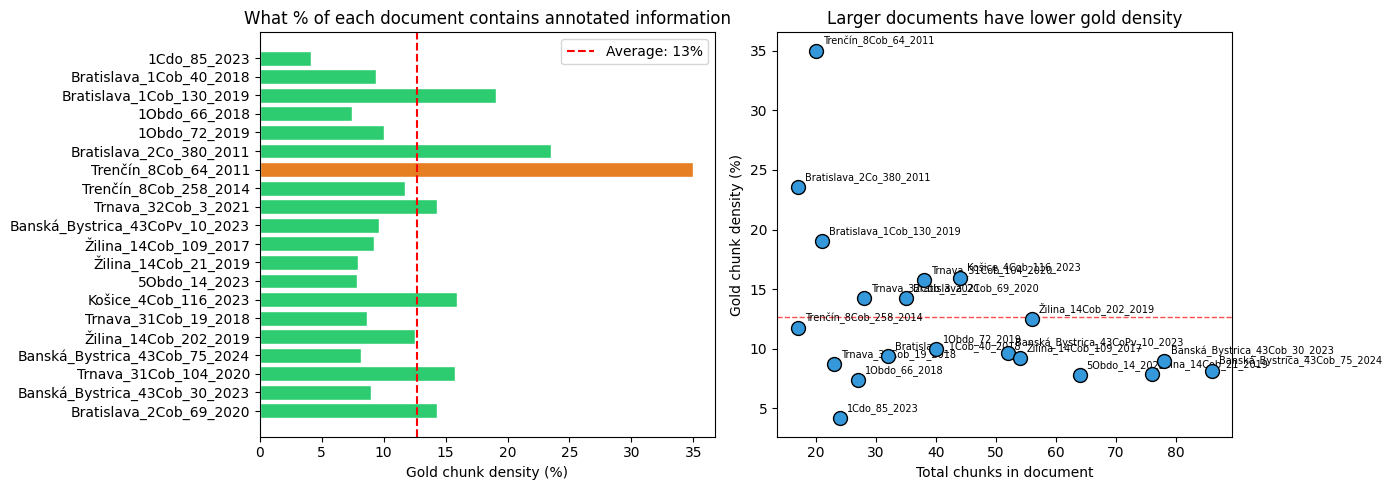

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: bar chart of gold % per document
docs = [r["doc"].replace("KS_", "").replace("NS_SR_", "") for r in results]
gold_pcts = [r["gold_pct"] for r in results]
colors = ["#2ecc71" if p <= 33 else "#e67e22" for p in gold_pcts]

ax = axes[0]
ax.barh(docs, gold_pcts, color=colors, edgecolor="white")
ax.axvline(avg_pct, color="red", linestyle="--", linewidth=1.5, label=f"Average: {avg_pct:.0f}%")
ax.set_xlabel("Gold chunk density (%)")
ax.set_title("What % of each document contains annotated information")
ax.legend()
ax.invert_yaxis()

# right: scatter of document size vs gold density
ax = axes[1]
sizes = [r["total_chunks"] for r in results]
ax.scatter(sizes, gold_pcts, s=100, c="#3498db", edgecolors="black", zorder=5)
for i, r in enumerate(results):
    label = r["doc"].replace("KS_", "").replace("NS_SR_", "")
    ax.annotate(label, (sizes[i], gold_pcts[i]),
                textcoords="offset points", xytext=(5, 5), fontsize=7)
ax.set_xlabel("Total chunks in document")
ax.set_ylabel("Gold chunk density (%)")
ax.set_title("Larger documents have lower gold density")
ax.axhline(avg_pct, color="red", linestyle="--", linewidth=1, alpha=0.7)

plt.tight_layout()
plt.show()

## 5 — Recall vs coverage across retrieval configurations

How does actual retrieval coverage compare to the ~13 % theoretical minimum (= what the retriever would read if it picked only gold chunks)?

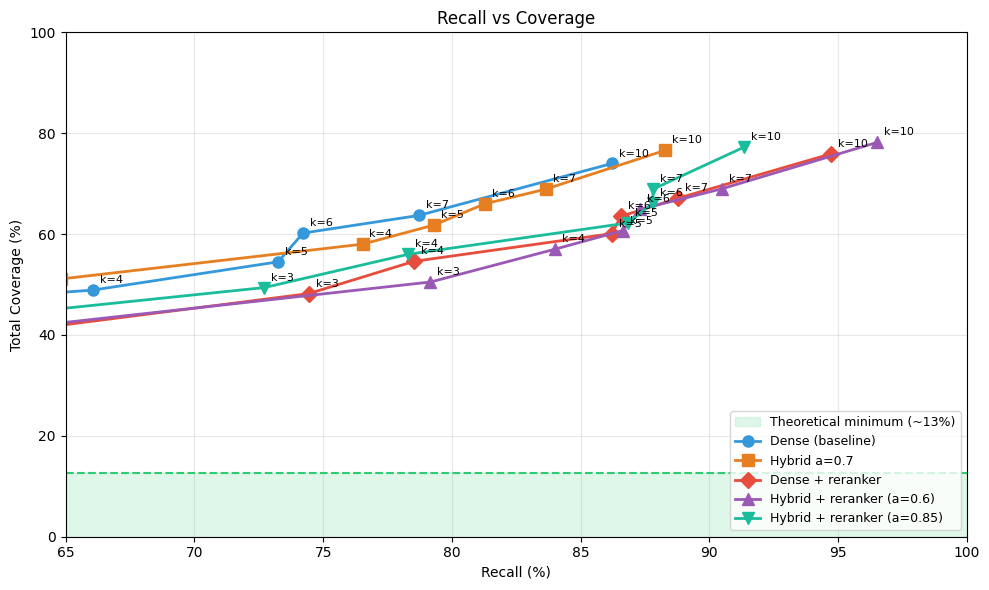

In [7]:
summary_csv = os.path.join(PROJECT_ROOT, "data/05_retrieval_evaluation/experiment_results_summary.csv")
df = pd.read_csv(summary_csv, sep=";")

configs_of_interest = [
    "openai3s_para", "hybrid_weighted_a7",
    "dense_reranked", "hybrid_a7_reranked", "hybrid_a7_reranked_a85",
]

rows = []
for _, r in df.iterrows():
    name = r["experiment_name"]
    parts = name.rsplit("_top", 1)
    if len(parts) != 2:
        continue
    base_name = parts[0]
    if base_name in configs_of_interest and r["window_size"] == 0:
        rows.append({"config": base_name, "top_k": r["top_k"],
                     "recall": r["recall_rate_percent"], "total_coverage": r["avg_total_cov"]})

exp_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 6))

ax.axhspan(0, avg_pct, color="#2ecc71", alpha=0.15, label=f"Theoretical minimum (~{avg_pct:.0f}%)")
ax.axhline(avg_pct, color="#2ecc71", linestyle="--", linewidth=1.5)

style_map = {
    "openai3s_para":          {"marker": "o", "color": "#3498db", "label": "Dense (baseline)"},
    "hybrid_weighted_a7":     {"marker": "s", "color": "#e67e22", "label": "Hybrid a=0.7"},
    "dense_reranked":         {"marker": "D", "color": "#e74c3c", "label": "Dense + reranker"},
    "hybrid_a7_reranked":     {"marker": "^", "color": "#9b59b6", "label": "Hybrid + reranker (a=0.6)"},
    "hybrid_a7_reranked_a85": {"marker": "v", "color": "#1abc9c", "label": "Hybrid + reranker (a=0.85)"},
}

for config_name, style in style_map.items():
    subset = exp_df[exp_df["config"] == config_name].sort_values("top_k")
    if subset.empty:
        continue
    ax.plot(subset["recall"], subset["total_coverage"],
            marker=style["marker"], color=style["color"],
            label=style["label"], linewidth=2, markersize=8)
    for _, point in subset.iterrows():
        ax.annotate(f"k={int(point['top_k'])}",
                    (point["recall"], point["total_coverage"]),
                    textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_xlabel("Recall (%)")
ax.set_ylabel("Total Coverage (%)")
ax.set_title("Recall vs Coverage")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim(65, 100)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6 — Summary

Findings:

- Only about **13 %** of paragraph chunks contain expert-annotated quotes on
  average (per-document mean across 20 golden documents). The rest is
  procedural text (case history, party identification, legal references)
  that is not needed for penalty extraction.
- Larger documents have lower gold density. They contain more procedural
  content while the penalty-relevant parts stay roughly the same size.
- Call 2 (court decision / reasoning) needs fewer gold chunks (~6 % per
  document) than Call 1 (breach context + penalty details, ~9 %).
- The full corpus has 176 documents with a median of 27 paragraph chunks
  (~5762 tokens). Most documents fit into a modern LLM context window
  without RAG, but RAG still focuses the LLM on relevant parts instead
  of letting it scan pages of procedural text. For long documents
  (50+ chunks, 25k+ tokens) this benefit is biggest.
- **Final configuration: `hybrid_a7_reranked_top7_w0`** — 90.5 % quote
  recall at 60.7 % weighted coverage. The LLM reads about 60 % of each
  document on average instead of the full text.